In [14]:
from langgraph.graph import StateGraph,START,END,MessagesState 
from langchain_core.messages import HumanMessage, SystemMessage
import sys
import os

sys.path.append(os.path.abspath(".."))
from myllm import get_llm
myllm = get_llm()

def ask_llm(state: MessagesState):
    messages = state["messages"]    
    response = myllm.invoke(messages)
    
    return {
        "messages": messages + [response]
    }

In [15]:
graph = StateGraph(MessagesState)
graph.add_node("AskMeAnything", ask_llm)

In [16]:
graph.add_edge(START, "AskMeAnything")
graph.add_edge("AskMeAnything", END)

In [17]:
state_graph = graph.compile()

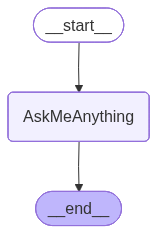

In [11]:
state_graph

In [21]:
result = state_graph.invoke({
    "messages": [HumanMessage(content="What is RAG in 5 lines")]
})

print(result["messages"][-1].content)

RAG (Retrieval-Augmented Generation) enhances Large Language Models (LLMs).
It first retrieves relevant information from an external knowledge base based on a user's query.
This retrieved data is then provided as additional context to the LLM.
The LLM uses this context to generate more accurate, factual, and up-to-date answers.
This helps prevent "hallucinations" and grounds responses in verified external data.
